In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("/content/Employee_Attrition_DataSet.csv")
df

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP9995,51,Marketing,4,28,14510,4,1,No,14.0,No,3,17,No
9996,EMP9996,22,Engineering,1,0,5659,3,3,Yes,25.3,No,3,19,Yes
9997,EMP9997,30,Sales,1,0,4223,3,4,Yes,15.8,No,2,20,No
9998,EMP9998,42,Engineering,2,2,7990,5,3,No,5.7,No,3,25,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  object 
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  object 
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  object 
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  object 
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 1.1+ M

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.describe()

,Age,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome,PerformanceRating,TrainingHoursLastYear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,37.693500,2.380800,7.788400,8967.918800,3.362100,2.761500,9.91074,2.603800,14.993100
std,9.376457,1.141368,7.141941,3500.745748,1.059951,0.893027,6.97463,0.737889,3.886227
min,22.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,1.00000,1.000000,2.000000
25%,31.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,4.70000,2.000000,12.000000
50%,37.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,8.30000,3.000000,15.000000
75%,44.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,13.40000,3.000000,18.000000
max,60.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,50.00000,4.000000,31.000000


In [ ]:
df.isnull().sum()

,0
EmployeeID,0
Age,0
Department,0
JobLevel,0
YearsAtCompany,0
MonthlyIncome,0
JobSatisfaction,0
WorkLifeBalance,0
OverTime,0
DistanceFromHome,0


In [ ]:
df.columns

Index(['EmployeeID', 'Age', 'Department', 'JobLevel', 'YearsAtCompany',
       'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'OverTime',
       'DistanceFromHome', 'PromotionLast5Years', 'PerformanceRating',
       'TrainingHoursLastYear', 'Attrition'],
      dtype='object')

In [ ]:
df.drop(columns=["EmployeeID"], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'JobLevel': 0, 'YearsAtCompany': 142, 'MonthlyIncome': 12, 'JobSatisfaction': 500, 'WorkLifeBalance': 0, 'DistanceFromHome': 306, 'PerformanceRating': 0, 'TrainingHoursLastYear': 15}


In [ ]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                  Column  Outlier_Count
4        JobSatisfaction            500
6       DistanceFromHome            306
2         YearsAtCompany            142
8  TrainingHoursLastYear             15
3          MonthlyIncome             12
0                    Age              0
1               JobLevel              0
5        WorkLifeBalance              0
7      PerformanceRating              0


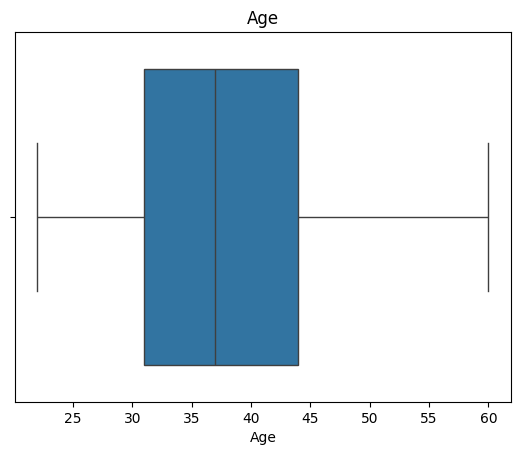

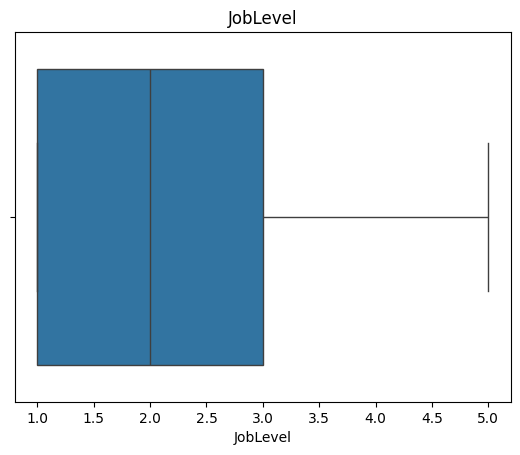

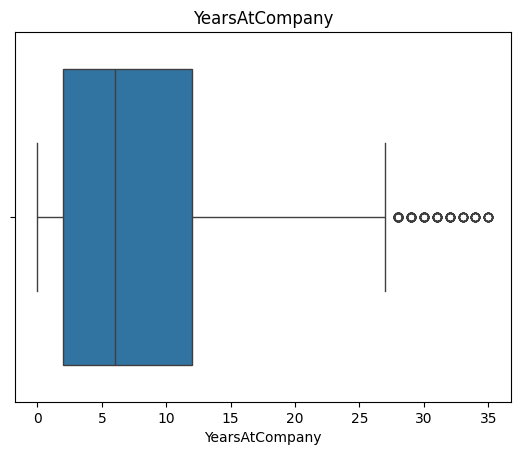

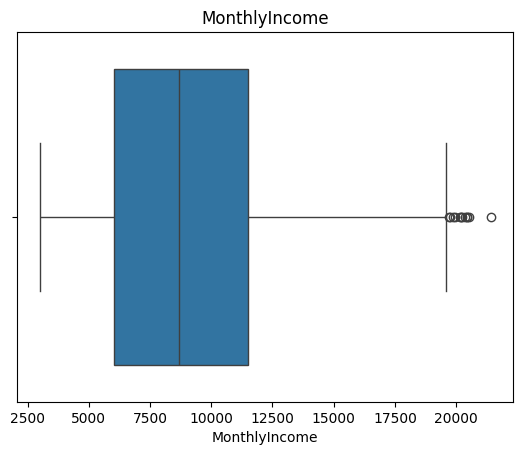

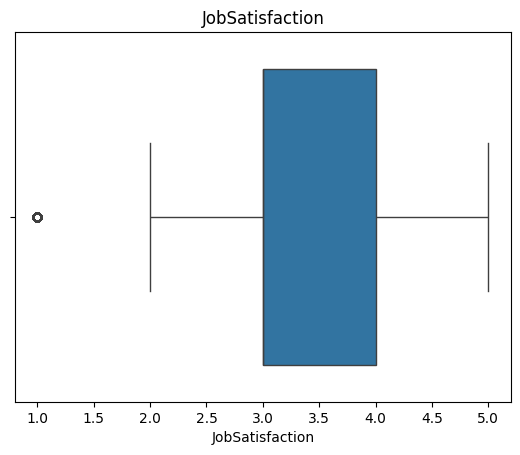

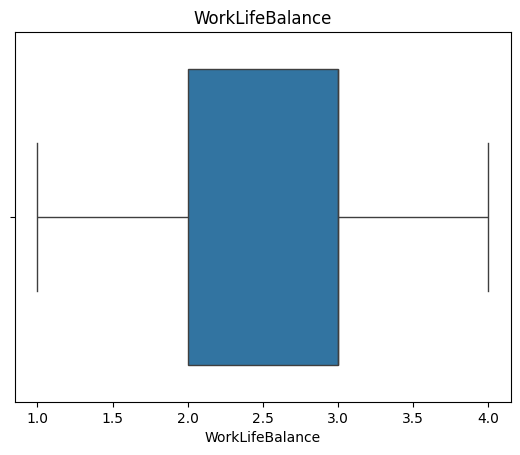

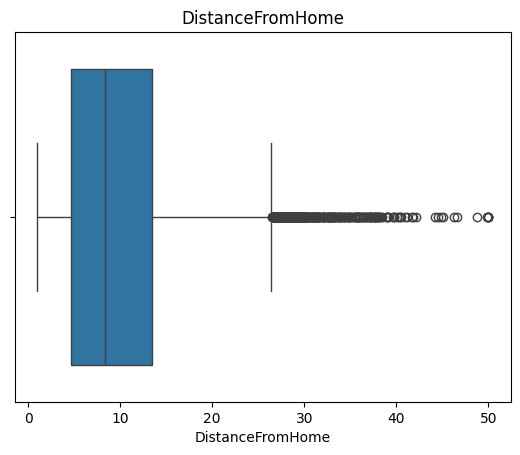

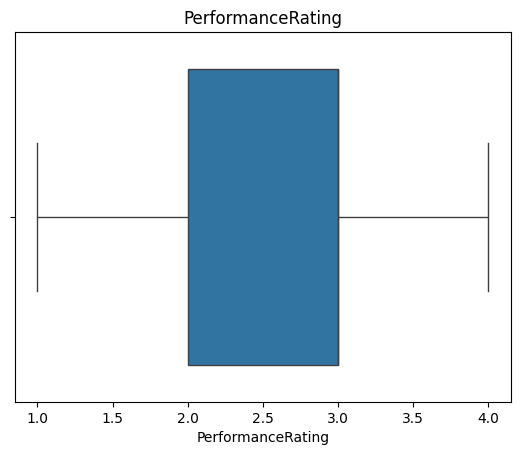

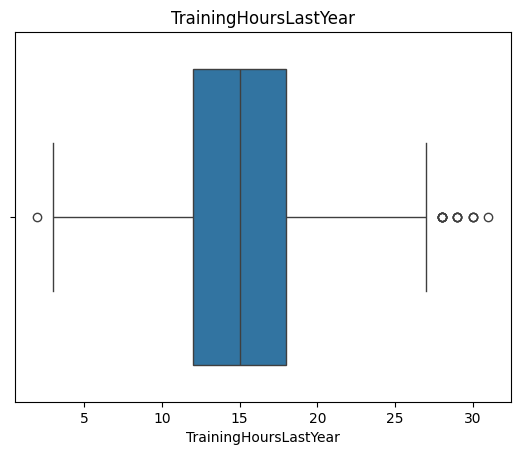

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
cols_to_cap = [
    'YearsAtCompany',
    'MonthlyIncome',
    'JobSatisfaction',
    'DistanceFromHome',
    'TrainingHoursLastYear',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

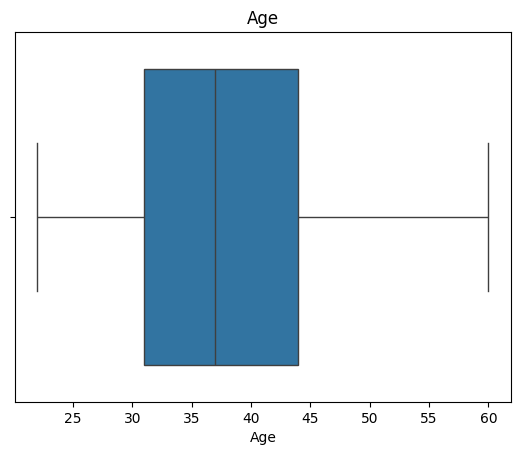

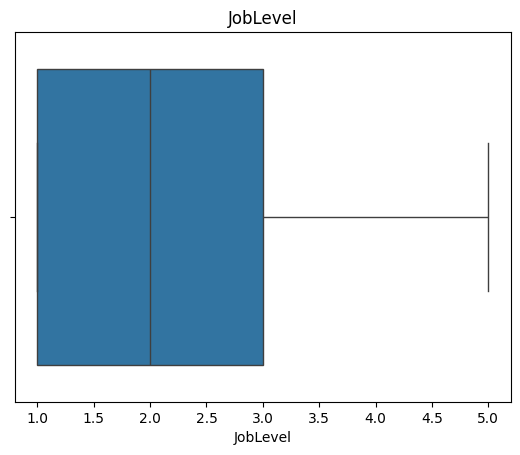

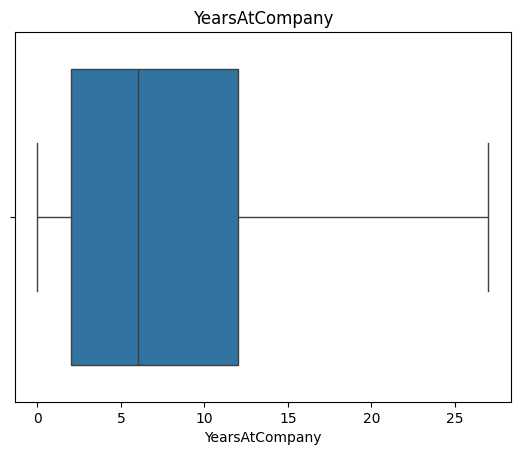

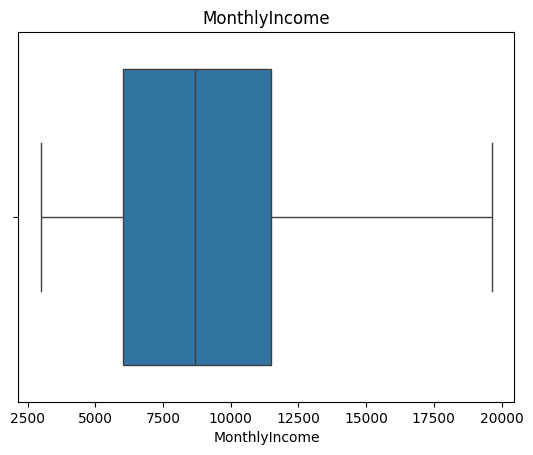

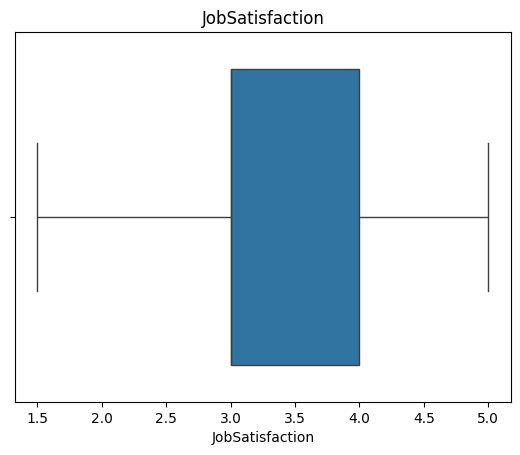

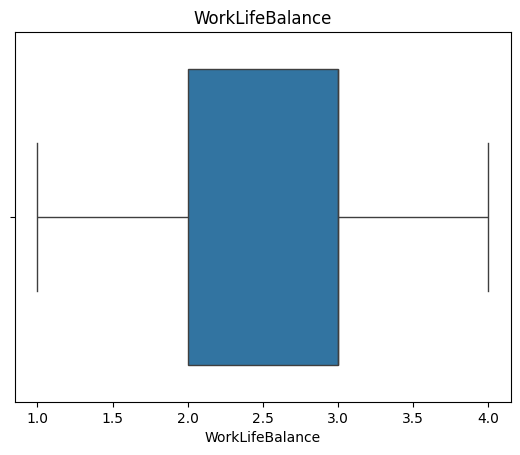

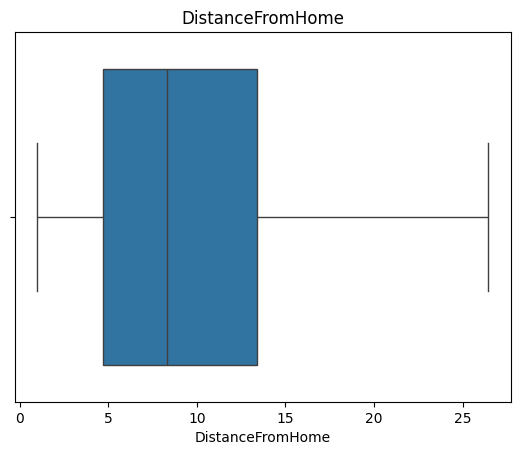

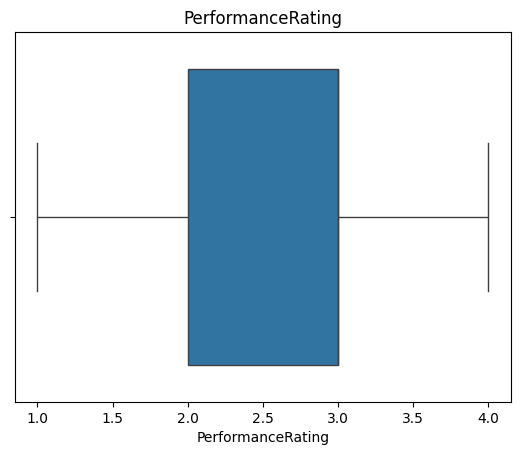

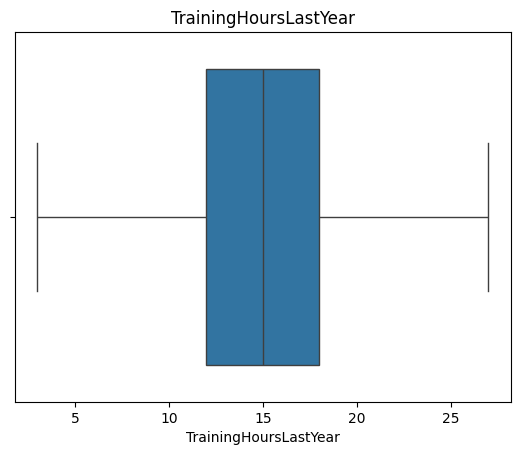

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df['Attrition'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,9097
Yes,903


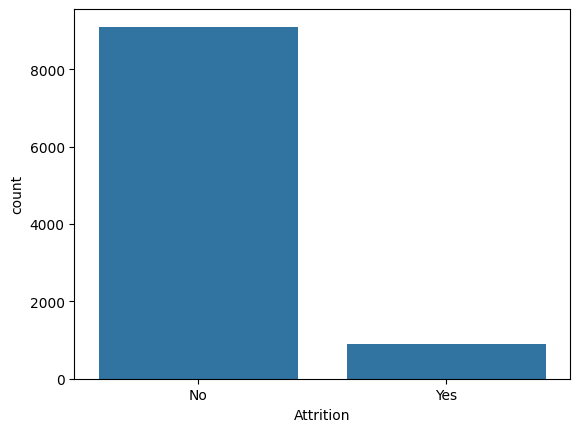

In [ ]:
sns.countplot(x=df["Attrition"])
plt.show()

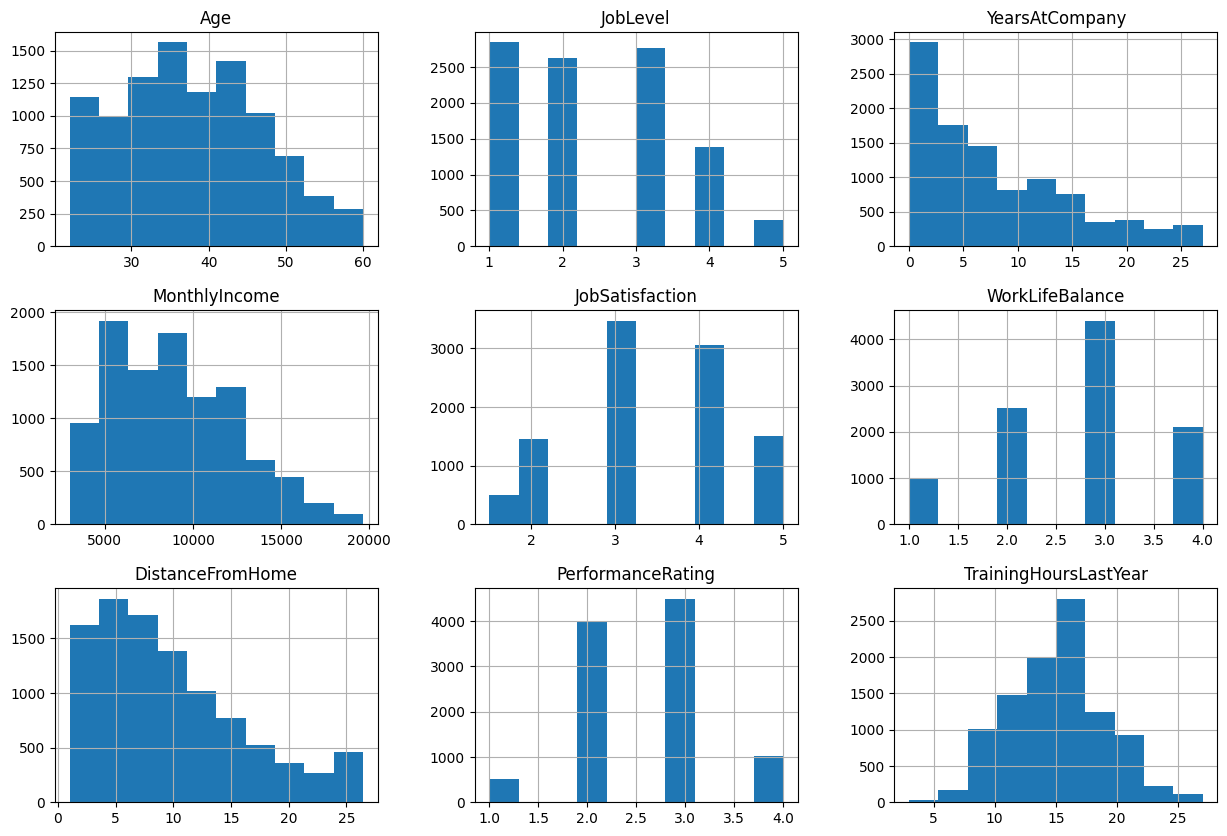

In [ ]:
df.hist(figsize=(15,10))
plt.show()

In [ ]:
df.dtypes

,0
Age,int64
Department,object
JobLevel,int64
YearsAtCompany,int64
MonthlyIncome,float64
JobSatisfaction,float64
WorkLifeBalance,int64
OverTime,object
DistanceFromHome,float64
PromotionLast5Years,object


In [ ]:
nominal_cols = ["Department","OverTime","PromotionLast5Years","Attrition"]
df = pd.get_dummies(df,columns=nominal_cols,drop_first=True)

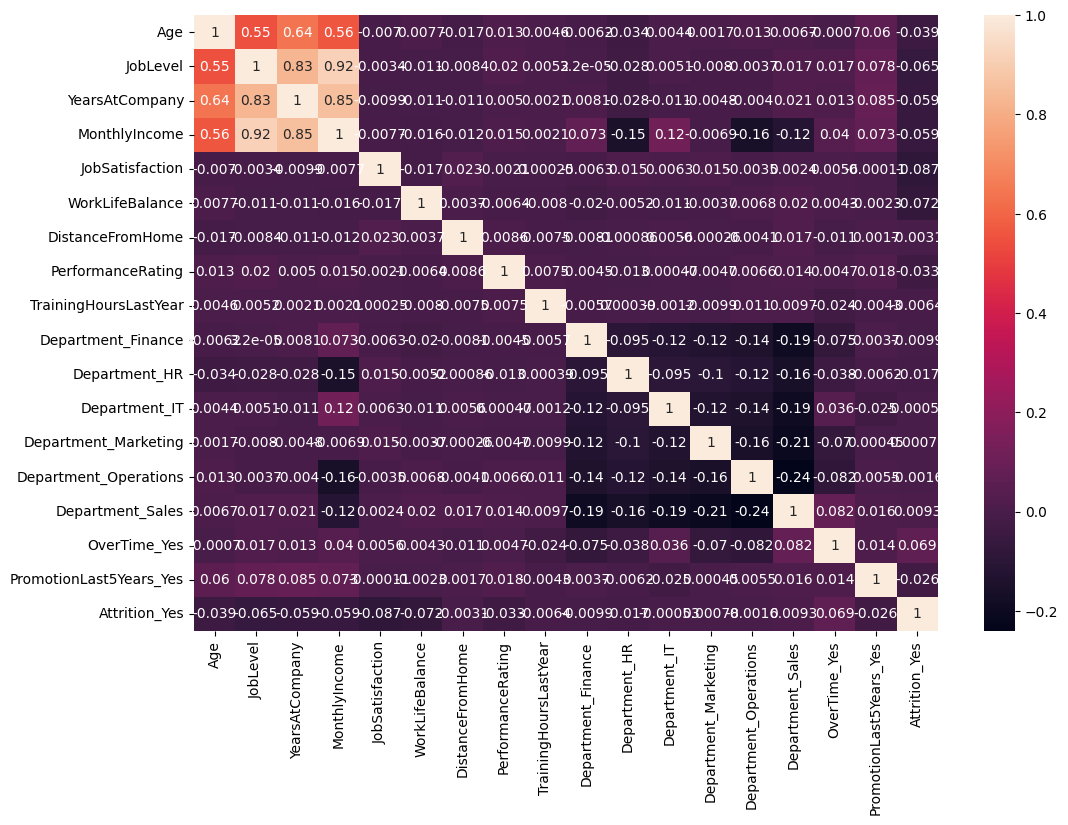

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
print(df.columns.tolist())


['Age', 'JobLevel', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome', 'PerformanceRating', 'TrainingHoursLastYear', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Operations', 'Department_Sales', 'OverTime_Yes', 'PromotionLast5Years_Yes', 'Attrition_Yes']


In [ ]:
X = df.drop("Attrition_Yes", axis=1)

y = df["Attrition_Yes"]

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [93]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=10.07,
    random_state=42,
    eval_metric="logloss"
)

In [94]:
model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [95]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]


In [96]:
from sklearn.metrics import accuracy_score

print("Training Accuracy:", model.score(X_train_sm, y_train_sm))
print("Testing Accuracy :", model.score(X_test, y_test))

Training Accuracy: 0.8207611981313547
Testing Accuracy : 0.5955


In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.60      0.73      1819
        True       0.12      0.54      0.20       181

    accuracy                           0.60      2000
   macro avg       0.52      0.57      0.46      2000
weighted avg       0.86      0.60      0.68      2000



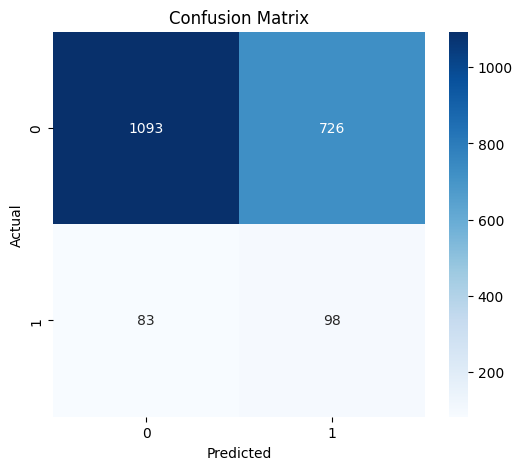

In [98]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [99]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)

print("Average CV Score:", scores.mean())


Cross Validation Scores: [0.7515 0.751  0.77   0.76   0.774 ]
Average CV Score: 0.7613


In [100]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)



AUC Score: 0.6082754473194245


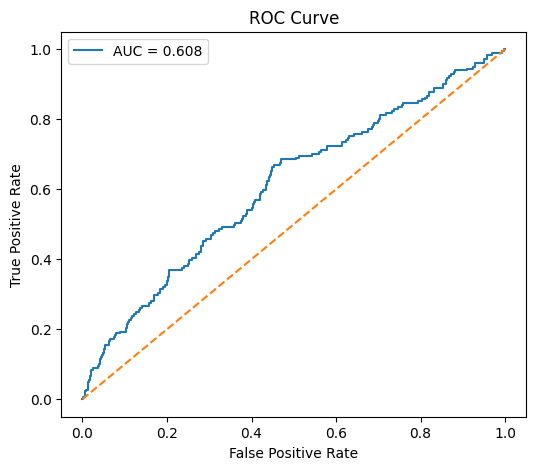

In [102]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = %.3f"%auc_score)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()



In [103]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                    Feature  Importance
15             OverTime_Yes    0.237659
5           WorkLifeBalance    0.169793
4           JobSatisfaction    0.130124
7         PerformanceRating    0.063374
1                  JobLevel    0.052115
13    Department_Operations    0.038591
12     Department_Marketing    0.036821
14         Department_Sales    0.035916
10            Department_HR    0.034407
11            Department_IT    0.033725
9        Department_Finance    0.031457
3             MonthlyIncome    0.026452
2            YearsAtCompany    0.025149
6          DistanceFromHome    0.024147
16  PromotionLast5Years_Yes    0.021692
0                       Age    0.020188
8     TrainingHoursLastYear    0.018389


In [104]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [105]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [106]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [10.07]
}

In [107]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [108]:
random_search.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'scale_pos_weight': [10.07],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [109]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'scale_pos_weight': 10.07, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV Score:
0.9723224245815267


In [110]:
best_model = random_search.best_estimator_

In [111]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [112]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Training Accuracy:", best_model.score(X_train, y_train))
print("Testing Accuracy:", best_model.score(X_test, y_test))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_prob))

Training Accuracy: 0.9605
Testing Accuracy: 0.818
              precision    recall  f1-score   support

       False       0.92      0.88      0.90      1819
        True       0.14      0.20      0.17       181

    accuracy                           0.82      2000
   macro avg       0.53      0.54      0.53      2000
weighted avg       0.85      0.82      0.83      2000

[[1599  220]
 [ 144   37]]
AUC Score: 0.5779995687023712
